# Probability and Statistics MT-2005
## Project 2
### Classification through Naive Bayes and Decision Trees

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Loading and cleaning data

In [47]:
df = pd.read_csv("adult.csv")
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

Encoding our target variable

Based on what you have been taught in class, explain why encoding is done in this situation. Explore the difference between one hot encoding and the encoding performed here.  

Create a new text markdown at the end of the file and label it as 'Why do we encode?'

In [48]:
# Convert income to binary (0 and 1)
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

print(df["income"].value_counts())

income
0    34014
1    11208
Name: count, dtype: int64


Seperating Numerical and Categorical Features

In [49]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=["int64"]).columns.tolist()
numerical_cols.remove("income")

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)


Numerical Columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical Columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


Train Test Split

In [50]:
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#Random state = 42 is a very common occurence in ML and AI. But rarely do people know why we use this particular value.
#Create a markdown at the end of the file and answer why this value is used. Label this markdown as 'Random State'

## Decision Tree of all features

In [51]:
# One-hot encoding for Decision Tree
X_encoded = pd.get_dummies(X)

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

y_pred_dt = dt_model.predict(X_test_dt)

print("Decision Tree Accuracy:", accuracy_score(y_test_dt, y_pred_dt))
print(classification_report(y_test_dt, y_pred_dt))

Decision Tree Accuracy: 0.853510226644555
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      6842
           1       0.80      0.53      0.64      2203

    accuracy                           0.85      9045
   macro avg       0.83      0.74      0.77      9045
weighted avg       0.85      0.85      0.84      9045



## Gaussian Naive Bayes for numeric features

In [52]:
# Use only numerical features
X_num = df[numerical_cols]

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

# Standardize features (important for Gaussian NB)
scaler = StandardScaler()
X_train_g = scaler.fit_transform(X_train_g)
X_test_g = scaler.transform(X_test_g)

gnb = GaussianNB()
gnb.fit(X_train_g, y_train_g)

y_pred_gnb = gnb.predict(X_test_g)

print("Gaussian NB Accuracy:", accuracy_score(y_test_g, y_pred_gnb))
print(classification_report(y_test_g, y_pred_gnb))

Gaussian NB Accuracy: 0.7911553344389165
              precision    recall  f1-score   support

           0       0.81      0.95      0.87      6842
           1       0.66      0.30      0.41      2203

    accuracy                           0.79      9045
   macro avg       0.73      0.62      0.64      9045
weighted avg       0.77      0.79      0.76      9045



## Multinomial Naive Bayes for categorical features

In [53]:
# Use only categorical features
X_cat = pd.get_dummies(df[categorical_cols])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_cat, y, test_size=0.2, random_state=42
)

mnb = MultinomialNB()
mnb.fit(X_train_m, y_train_m)

y_pred_mnb = mnb.predict(X_test_m)

print("Multinomial NB Accuracy:", accuracy_score(y_test_m, y_pred_mnb))
print(classification_report(y_test_m, y_pred_mnb))

Multinomial NB Accuracy: 0.7945826423438364
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      6842
           1       0.56      0.75      0.64      2203

    accuracy                           0.79      9045
   macro avg       0.73      0.78      0.75      9045
weighted avg       0.82      0.79      0.80      9045



### Comparison of all three models

Based on what you have studied in class, make a comment on why the accuracies of these models vary.

Label this cell as 'Accuracy Difference'

In [54]:
print("Model Comparison:")
print("Decision Tree Accuracy :", accuracy_score(y_test_dt, y_pred_dt))
print("Gaussian NB Accuracy   :", accuracy_score(y_test_g, y_pred_gnb))
print("Multinomial NB Accuracy:", accuracy_score(y_test_m, y_pred_mnb))

Model Comparison:
Decision Tree Accuracy : 0.853510226644555
Gaussian NB Accuracy   : 0.7911553344389165
Multinomial NB Accuracy: 0.7945826423438364


The values of train test split can be changed to give varying results. You are required to use 3-4 values of the test split, for each of the models, and observe the difference in outputs.

Enter your answer at the end of the file in a new markdown. Label this as 'Train Test Split'

**Confusion Matrix for Decision Tree**

At the end of the notebook, make a comment on what confusion matrices are for and what does this confusion matrix tell us about the classification.

Label this markdown as confusion matrix


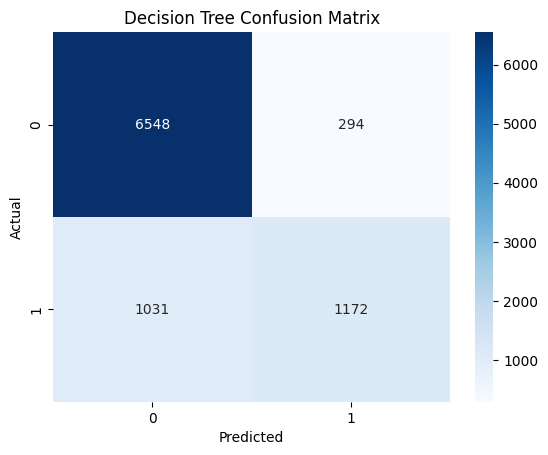

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_dt, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

**Confusion Matrix for Naive Bayes (Multinomial)**



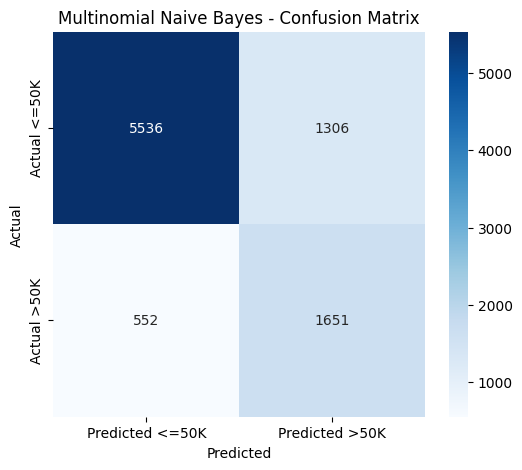

In [56]:
from sklearn.metrics import confusion_matrix

cm_mnb = confusion_matrix(y_test_m, y_pred_mnb)
cm_df = pd.DataFrame(
    cm_mnb,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

**Confusion Matrix for Naives Bayes (Gaussian)**

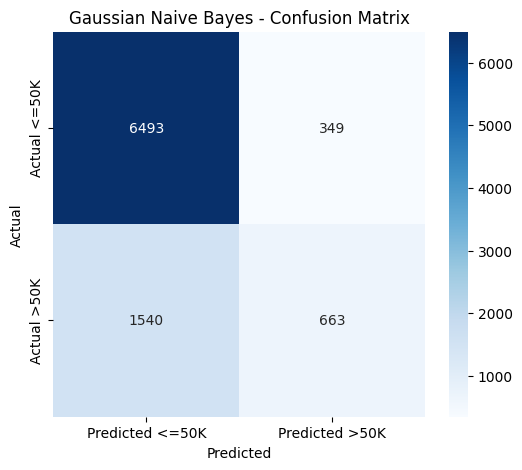

In [57]:
from sklearn.metrics import confusion_matrix
cm_gnb = confusion_matrix(y_test_g, y_pred_gnb)

cm_df_gnb = pd.DataFrame(
    cm_gnb,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)
plt.figure(figsize=(6,5))
sns.heatmap(cm_df_gnb, annot=True, fmt="d", cmap="Blues")

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

Which of the classifiers is more suited for the datset that we have used ?

Label this markdown as 'Classifier choice'

Visualising the classifications?

The designer of this project had a questionable moment of brilliance and he thought that 'why not visualise the classification?'; but soon he realised his error. :)

Explain why visualisation is impractical and hard to interpret in this scenario.

Label this cell as 'Visualisation'

## Experimenting with metrics of Decision Tree Classifier

The sklearn library uses Gini Impurity as its default metric for classification. But in class you have learned Information gain.
This section requries you to explore the difference in outputs of two out of three metrics: Gini imprity, Information gain, and Log Loss.

Tree Train with Gini

In [58]:
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

dt_gini.fit(X_train_dt, y_train_dt)

y_pred_gini = dt_gini.predict(X_test_dt)

print("Gini Accuracy:", accuracy_score(y_test_dt, y_pred_gini))

Gini Accuracy: 0.8427860696517413


Train Tree with Entropy (Information Gain)

In [59]:
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

dt_entropy.fit(X_train_dt, y_train_dt)

y_pred_entropy = dt_entropy.predict(X_test_dt)

print("Entropy Accuracy:", accuracy_score(y_test_dt, y_pred_entropy))

Entropy Accuracy: 0.8432283029297954


In [60]:
for i in range(25):
    print(f"Node {i}")
    print("  Entropy:", dt_entropy.tree_.impurity[i])
    print("  Gini   :", dt_gini.tree_.impurity[i])
    print()

Node 0
  Entropy: 0.8095539968290979
  Gini   : 0.3739127023229516

Node 1
  Entropy: 0.3626601583426009
  Gini   : 0.12869822504584327

Node 2
  Entropy: 0.29421364503802044
  Gini   : 0.09832717433599569

Node 3
  Entropy: 0.17111690847380895
  Gini   : 0.0739605277819565

Node 4
  Entropy: 0.04005487147634422
  Gini   : 0.06853444023453104

Node 5
  Entropy: 0.2491128155801777
  Gini   : 0.4940692089010881

Node 6
  Entropy: 0.6195762977118933
  Gini   : 0.3960856401384083

Node 7
  Entropy: 0.16725812083478725
  Gini   : 0.3012759924385633

Node 8
  Entropy: 0.7353151950688441
  Gini   : 0.4794558071585099

Node 9
  Entropy: 0.19549285017194654
  Gini   : 0.058613090206496854

Node 10
  Entropy: 0.9182958340544896
  Gini   : 0.0

Node 11
  Entropy: 0.0
  Gini   : 0.0433391395093653

Node 12
  Entropy: 0.5435644431995964
  Gini   : 0.4444444444444444

Node 13
  Entropy: 0.0916188303033645
  Gini   : 0.005865051903114149

Node 14
  Entropy: 0.0
  Gini   : 0.49603105858589347

Node 15

Visualising Trees

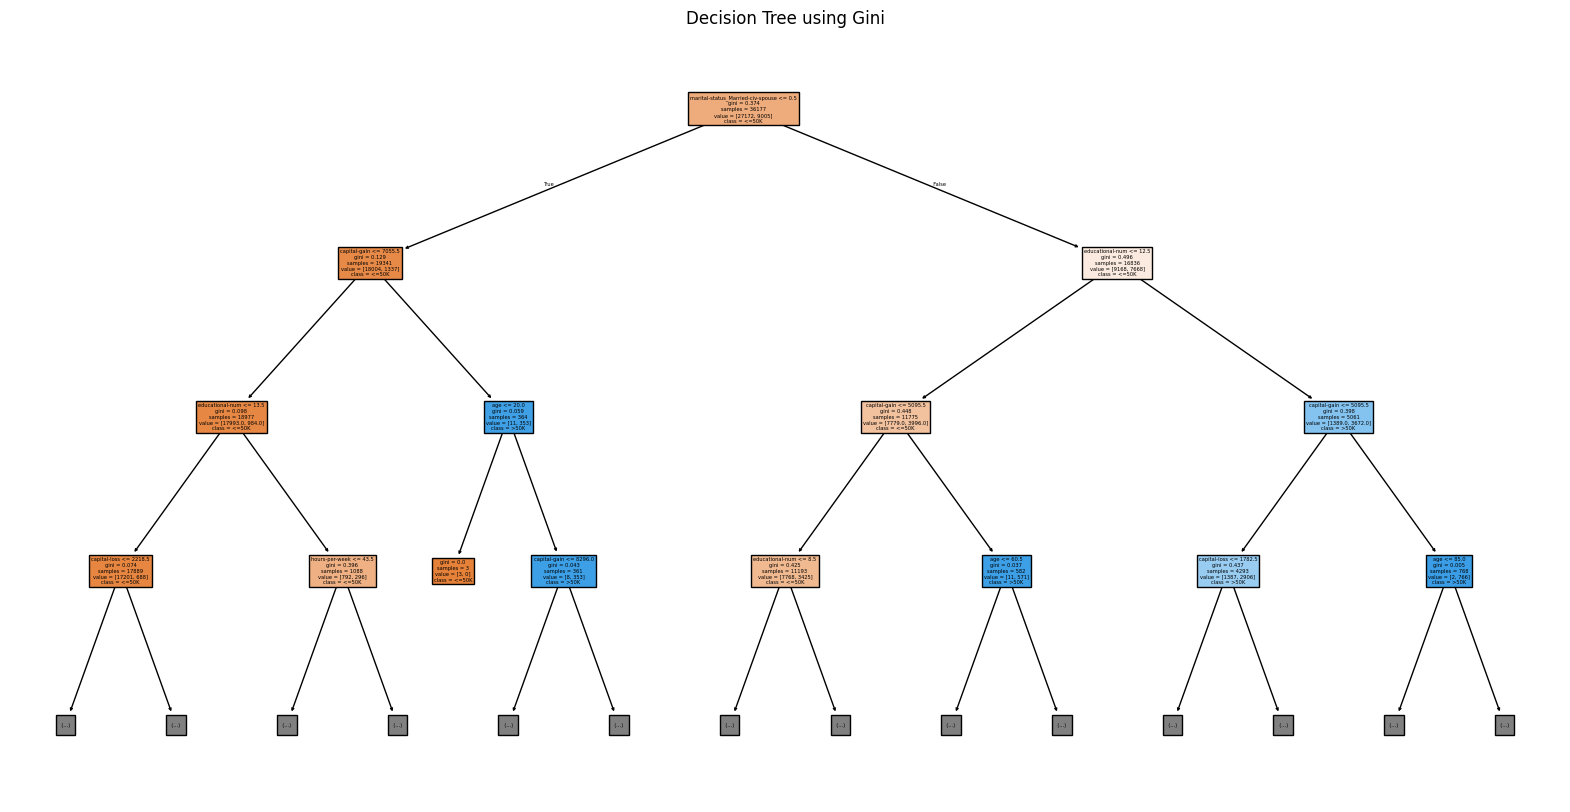

In [61]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt_gini,
          feature_names=X_encoded.columns,
          class_names=["<=50K", ">50K"],
          filled=True,
          max_depth=3)
plt.title("Decision Tree using Gini")
plt.show()

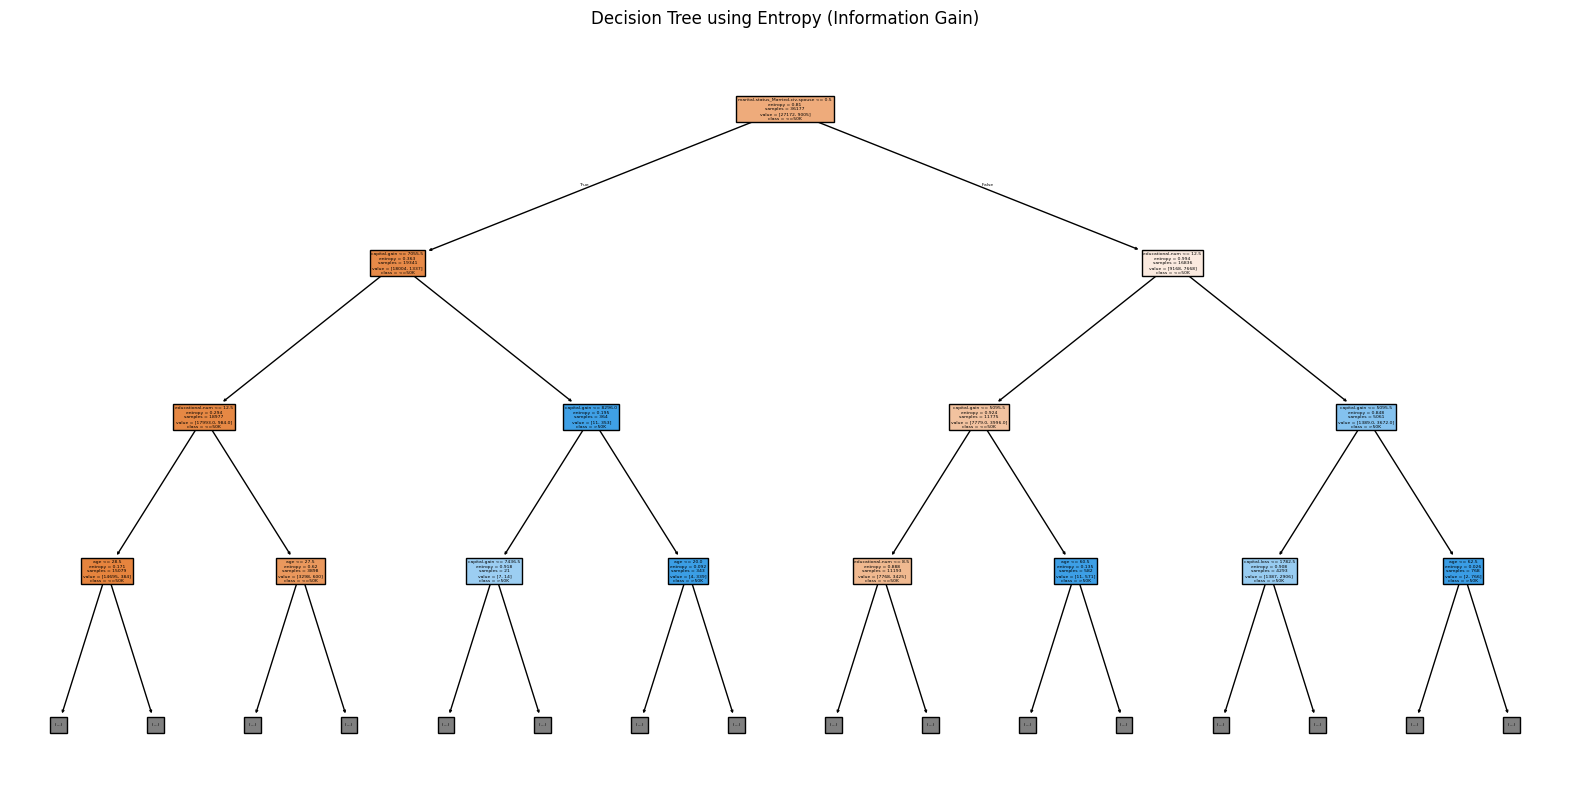

In [62]:
plt.figure(figsize=(20,10))
plot_tree(dt_entropy,
          feature_names=X_encoded.columns,
          class_names=["<=50K", ">50K"],
          filled=True,
          max_depth=3)
plt.title("Decision Tree using Entropy (Information Gain)")
plt.show()

Feature Importance changes

In [63]:
importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Gini Importance": dt_gini.feature_importances_,
    "Entropy Importance": dt_entropy.feature_importances_
})

importance_df.sort_values(by="Gini Importance", ascending=False).head(10)

,Feature,Gini Importance,Entropy Importance
31,marital-status_Married-civ-spouse,0.493860,0.490852
2,educational-num,0.245445,0.220670
3,capital-gain,0.228720,0.233103
4,capital-loss,0.026031,0.017583
5,hours-per-week,0.004419,0.000000
0,age,0.001525,0.037792
6,workclass_Federal-gov,0.000000,0.000000
1,fnlwgt,0.000000,0.000000
7,workclass_Local-gov,0.000000,0.000000
8,workclass_Private,0.000000,0.000000


In [64]:
print("Root impurity (Gini):", dt_gini.tree_.impurity[0])
print("Root impurity (Entropy):", dt_entropy.tree_.impurity[0])

Root impurity (Gini): 0.3739127023229516
Root impurity (Entropy): 0.8095539968290979


You are required to explore the mathematics behind Gini impurity and compare it with the information gain studied in class. You may write 4-5 sentences.

Label this cell as 'Decision Tree Metric Difference'